# Cross Validation of NMF

In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

sns.set("talk", "ticks", palette='colorblind')

## Write the Nonnegative Matrix Factorization Code that can handle missing data

In [3]:
from nnls import nnlsm_blockpivot as nnlstsq

def censored_nnlstsq(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n in range(B.shape[1]):
        X[n] = nnlstsq(T[n], rhs[n], is_input_prod=True)[0].T

    return X.T


def cv_nmf(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    This code was adapted from Alex Williams at Stanford (https://bit.ly/2KDqKoW).

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence - the solution has converged when
                        the MSE of subsequent iterations are less than this number
    verbose (bool)    : if True, print out debugging information
    max_itr (int)     : the maximum number of iterations for convergence

    Returns
    -------
    U (ndarray)       :
    Vt (ndarray)      :
    train_err (float) :
    test_err (float)  :
    converged (bool)  :

    """

    # create the masking matrix to decide which values to "hold out"
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout

        # check to make sure there are enough values in each row to avoid singular matrix issues
        if M.sum(axis=0).any() < rank:
            for i in range(M.shape[0]):
                if M[i].sum() < rank:
                    M[i, :] = [True]*M.shape[1]

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq(U, data, M)
        U = censored_nnlstsq(Vt.T, data.T, M.T).T

        # calculate the current iterations mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged

In [4]:
import numpy as np
import scipy.linalg as sla
import numpy.linalg as nla

# ---------- NNLS block-pivot solver ----------
def nnlsm_blockpivot(A, B, is_input_prod=False, init=None):
    """ Nonnegativity-constrained least squares with block principal pivoting. """
    if is_input_prod:
        AtA = A
        AtB = B
    else:
        AtA = A.T.dot(A)
        AtB = A.T.dot(B)

    n, k = AtB.shape
    X = np.zeros((n, k))
    Y = -AtB if init is None else AtA.dot(X) - AtB
    PassSet = np.zeros((n, k), dtype=bool)
    MAX_ITER = n * 5
    big_iter = 0
    success = True

    while True:
        not_opt_set = np.logical_and(Y < 0, ~PassSet)
        infea_set = np.logical_and(X < 0, PassSet)
        not_good = np.sum(not_opt_set, axis=0) + np.sum(infea_set, axis=0)
        not_opt_cols = (not_good > 0).nonzero()[0]
        if not_opt_cols.size == 0:
            break

        big_iter += 1
        if big_iter > MAX_ITER:
            success = False
            break

        # Solve each non-optimal column
        for j in not_opt_cols:
            cols = np.arange(n)
            if np.any(PassSet[:, j]):
                cols = cols[PassSet[:, j]]
            if cols.size > 0:
                x_new = nla.solve(AtA[np.ix_(cols, cols)], AtB[cols, j])
                X[cols, j] = np.maximum(x_new, 0)
        Y = AtA.dot(X) - AtB

    return X, (success, Y, 0, 0, 0)

# Assign to variable used in censored_nnlstsq
nnlstsq = nnlsm_blockpivot


In [5]:
def censored_nnlstsq(A, B, M):
    """
    Solves min ||M*(AX - B)|| subject to X >= 0
    A : m x r matrix
    B : m x n matrix
    M : mask of same shape as B, 1=observed, 0=missing
    """
    B_masked = M * B
    r = A.shape[1]
    n = B.shape[1]
    X = np.zeros((r, n))

    for j in range(n):
        b_col = B_masked[:, j].reshape(-1, 1)
        A_masked = A * M[:, j][:, np.newaxis]
        x_col, _ = nnlstsq(A_masked, b_col)
        X[:, j] = x_col.flatten()

    return X


In [6]:
# Example data
m, r, n = 5, 3, 4
A = np.random.rand(m, r)
B = np.random.rand(m, n)
M = (np.random.rand(m, n) > 0.2).astype(float)  # 80% observed, 20% missing

# Solve censored NNLS
X = censored_nnlstsq(A, B, M)
print("Solution X:\n", X)

Solution X:
 [[0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [1.75160193 5.01901165 3.38663912 2.63829327]]


In [7]:
# Make sure nnlsm_blockpivot is already defined in your notebook
# Assign it to nnlstsq
nnlstsq = nnlsm_blockpivot

def censored_nnlstsq(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n_idx in range(B.shape[1]):
        X[n_idx] = nnlstsq(T[n_idx], rhs[n_idx], is_input_prod=True)[0].T

    return X.T

def cv_nmf(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence
    verbose (bool)    : if True, print debugging information
    max_iter (int)    : maximum number of iterations

    Returns
    -------
    U (ndarray), Vt (ndarray), train_err (float), test_err (float), converged (bool)
    """

    # create the masking matrix to decide which values to "hold out"
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout

        # check to make sure there are enough values in each row to avoid singular matrix issues
        for i in range(M.shape[0]):
            if M[i].sum() < rank:
                M[i, :] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq(U, data, M)
        U = censored_nnlstsq(Vt.T, data.T, M.T).T

        # calculate the current iteration's mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged


## Let's try an example...

In [8]:
N, R = 150, 4

noise = 0.8
replicates = 10

ranks = np.arange(1, 8)

# initialize the problem
U = np.random.rand(N, R) # (150, 4)
Vt = np.random.rand(R, N) # (4, 150)

# create the data by making it noisy
data = np.dot(U, Vt) + noise * np.random.rand(N, N) # (150, 150)

frame = pd.DataFrame()

# fit the models
for rnk, _ in itertools.product(ranks, range(replicates)):
    tr, te, converged = cv_nmf(data, rnk, verbose=False)[2:]

    if converged:

        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train"},
            {"Rank": rnk, "MSE": te, "Group": "Test"},])

        frame = pd.concat([frame, new_rows], ignore_index=True)

    else:
        print ("there was a convergence issue: {}".format(rnk))

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

In [9]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.074276  0.000777  0.072472  0.073004  0.074530  0.074984   
      2     10.0  0.070755  0.002781  0.068738  0.068918  0.069909  0.075220   
      3     10.0  0.064609  0.001009  0.062968  0.063339  0.064372  0.066211   
      4     10.0  0.061151  0.002301  0.059623  0.059805  0.060375  0.064767   
      5     10.0  0.062140  0.000720  0.061163  0.061305  0.062009  0.063111   
      6     10.0  0.063726  0.000883  0.062721  0.062774  0.063714  0.065045   
      7     10.0  0.066308  0.001183  0.063503  0.064302  0.066602  0.067348   
Train 1     10.0  0.071490  0.000316  0.071208  0.071226  0.071428  0.072021   
      2     10.0  0.065123  0.002204  0.062839  0.062846  0.065126  0.068351   
      3     10.0  0.057433  0.000638  0.056546  0.056584  0.057412  0.058290   
      4     10.0  0.051758  0.001389  0.050970  0.051018  0.051213  0.053952   
      5     10.0  0.049686  0.000414  0.049055  0.049124  0.049702  0.050250   
      6     10.0  0.048350  0.000484  0.047616  0.047727  0.048402  0.049003   
      7     10.0  0.047031  0.000529  0.046234  0.046392  0.046987  0.047796   

                      
                 max  
Group Rank            
Test  1     0.075035  
      2     0.078332  
      3     0.066640  
      4     0.067518  
      5     0.063140  
      6     0.065081  
      7     0.067443  
Train 1     0.072262  
      2     0.070754  
      3     0.058433  
      4     0.055591  
      5     0.050460  
      6     0.049074  
      7     0.048252

## Plot the results

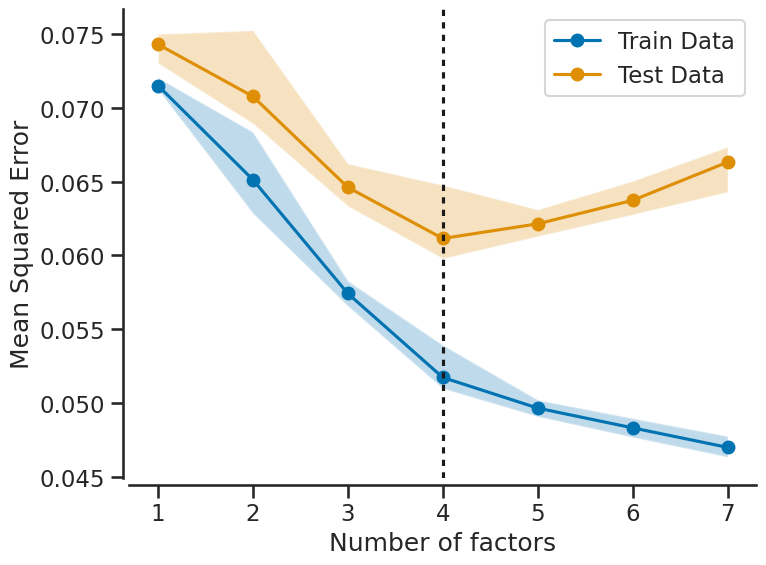

In [10]:
fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

inflection = (groups["MSE"]["mean"]["Test"] > groups["MSE"]["mean"]["Test"].shift()).idxmax() - 1

ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

## Trying on Our Data

In [11]:
# Make sure nnlsm_blockpivot is already defined in your notebook
nnlstsq = nnlsm_blockpivot

def censored_nnlstsq2(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None]  # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:])  # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n_idx in range(B.shape[1]):
        try:
            X[n_idx] = nnlstsq(T[n_idx], rhs[n_idx], is_input_prod=True)[0].T
        except np.linalg.LinAlgError:
            X[n_idx] = np.zeros((A.shape[1],))

    return X.T


def cv_nmf2(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    Args
    ----
    data (ndarray)    : m x n matrix
    rank (int)        : the desired output rank (number of factors)
    M (ndarray)       : m x n binary matrix (zeros indicate heldout values)
    p_holdout (float) : fraction of values to hold out
    tol (float)       : tolerance for convergence
    verbose (bool)    : print debug info
    max_iter (int)    : maximum iterations

    Returns
    -------
    U, Vt, train_err, test_err, converged
    """

    # create the masking matrix if not provided
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout
        min_valid = rank + 1

        # ensure enough True values per row
        for i in range(M.shape[0]):
            if M[i].sum() < min_valid:
                needed = min_valid - M[i].sum()
                zero_indices = np.where(~M[i])[0]
                if len(zero_indices) >= needed:
                    M[i, np.random.choice(zero_indices, size=needed, replace=False)] = True

        # ensure enough True values per column
        for j in range(M.shape[1]):
            if M[:, j].sum() < min_valid:
                needed = min_valid - M[:, j].sum()
                zero_indices = np.where(~M[:, j])[0]
                if len(zero_indices) >= needed:
                    M[np.random.choice(zero_indices, size=needed, replace=False), j] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    mse = 100
    converged = False

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq2(U, data, M)
        U = censored_nnlstsq2(Vt.T, data.T, M.T).T

        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse

        if verbose:
            train_pct = 100 * M.sum() / M.size
            print(f"\tIter {itr+1} = {diff:.5f}")
            print(f"\tTrain/Test = {train_pct:.2f}/{100-train_pct:.2f}")

    # compute train/test errors
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged


In [12]:
#importing data from Modulair MOD-00688
df = pd.read_csv(r'/content/MOD-00688.csv')
df.head()

,timestamp,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T07:32:44Z,577143173,2025-12-31T02:32:44Z,MOD-00688,44.0,-2.3,0.983,0.108,0.042,0.008,...,35.320,38.781,14337.0,14338.0,14339.0,14475.0,14500.0,14550.0,14525.0,3.41
1,2025-12-31T07:31:44Z,577143170,2025-12-31T02:31:44Z,MOD-00688,44.0,-2.3,1.003,0.086,0.034,0.008,...,35.320,39.128,14337.0,14338.0,14339.0,14475.0,14500.0,14550.0,14525.0,2.29
2,2025-12-31T07:30:44Z,577143172,2025-12-31T02:30:44Z,MOD-00688,44.0,-2.3,1.187,0.079,0.021,0.005,...,35.556,38.781,14337.0,14338.0,14339.0,14475.0,14500.0,14550.0,14525.0,2.25
3,2025-12-31T07:29:44Z,577143171,2025-12-31T02:29:44Z,MOD-00688,43.6,-2.3,0.912,0.083,0.043,0.019,...,34.863,40.180,14337.0,14338.0,14339.0,14475.0,14500.0,14550.0,14525.0,2.89
4,2025-12-31T07:28:44Z,577141355,2025-12-31T02:28:44Z,MOD-00688,43.5,-2.3,1.069,0.099,0.030,0.006,...,34.630,40.183,14337.0,14338.0,14339.0,14475.0,14500.0,14550.0,14525.0,4.20


In [13]:
#only including columns of interest and non na rows
COLS_TO_INCLUDE = ['timestamp_local','co', 'no2', 'o3', 'no', 'bin0', 'bin1', 'bin2','bin3','bin4','bin5']
df = df[COLS_TO_INCLUDE]
df.dropna()
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-31T02:32:44Z,743.444,35.320,38.781,1.892,0.983,0.108,0.042,0.008,0.010,0.008
1,2025-12-31T02:31:44Z,740.981,35.320,39.128,1.892,1.003,0.086,0.034,0.008,0.003,0.005
2,2025-12-31T02:30:44Z,726.613,35.556,38.781,1.892,1.187,0.079,0.021,0.005,0.008,0.000
3,2025-12-31T02:29:44Z,698.983,34.863,40.180,1.891,0.912,0.083,0.043,0.019,0.005,0.000
4,2025-12-31T02:28:44Z,674.834,34.630,40.183,1.891,1.069,0.099,0.030,0.006,0.003,0.003


In [14]:
#converting to datetime
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-31 02:32:44,743.444,35.320,38.781,1.892,0.983,0.108,0.042,0.008,0.010,0.008
1,2025-12-31 02:31:44,740.981,35.320,39.128,1.892,1.003,0.086,0.034,0.008,0.003,0.005
2,2025-12-31 02:30:44,726.613,35.556,38.781,1.892,1.187,0.079,0.021,0.005,0.008,0.000
3,2025-12-31 02:29:44,698.983,34.863,40.180,1.891,0.912,0.083,0.043,0.019,0.005,0.000
4,2025-12-31 02:28:44,674.834,34.630,40.183,1.891,1.069,0.099,0.030,0.006,0.003,0.003


In [15]:
#taking hourly average of df. round to floor of the hour
df = df.groupby(df['timestamp_local'].dt.floor('h')).agg(co = ('co','mean'),
                                                         no2 = ('no2','mean'),
                                                         o3 = ('o3','mean'),
                                                         no = ('no','mean'),
                                                         bin0 = ('bin0','mean'),
                                                         bin1 = ('bin1','mean'),
                                                         bin2 = ('bin2','mean'),
                                                         bin3 = ('bin3','mean'),
                                                         bin4 = ('bin4','mean'),
                                                         bin5 = ('bin5','mean')).reset_index()

df = df.round(decimals = 2)
df = df.dropna()

In [16]:
df.to_csv('MOD-00688_timeseries_hourly_scaled.csv')

In [17]:
df = df.sample(frac=0.2)
df = df.set_index('timestamp_local')

def maximum_absolute_scaling(df):
    # copy the dataframe
    df_scaled = df.copy()
    # apply maximum absolute scaling
    for column in df_scaled.columns:
        df_scaled[column] = df_scaled[column]  / df_scaled[column].abs().max()
    return df_scaled

# call the maximum_absolute_scaling function
df_scaled = maximum_absolute_scaling(df)

df_scaled.head(10)

,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
timestamp_local,,,,,,,,,,
2025-05-01 04:00:00,0.426326,0.615065,0.642327,0.040357,0.021367,0.005201,0.005314,0.006042,0.011029,0.012048
2025-04-09 13:00:00,0.440504,0.294252,0.731084,0.123195,0.025923,0.007429,0.007972,0.009063,0.007353,0.012048
2025-04-30 14:00:00,0.373625,0.158747,0.710563,0.052676,0.015082,0.005201,0.004429,0.006042,0.007353,0.024096
2025-07-08 18:00:00,0.550876,0.509027,0.779932,0.062872,0.119246,0.018202,0.015058,0.012085,0.022059,0.048193
2025-08-27 08:00:00,0.410973,0.202947,0.413068,0.051189,0.031422,0.007429,0.006200,0.006042,0.007353,0.024096
2025-11-08 15:00:00,0.397579,0.617348,0.549540,0.052039,0.031422,0.006315,0.006200,0.006042,0.011029,0.024096
2025-04-19 03:00:00,0.604720,0.779415,0.465819,0.045455,0.140141,0.063150,0.085031,0.126888,0.227941,0.554217
2025-09-20 07:00:00,0.421312,0.618801,0.502581,0.050127,0.017596,0.005201,0.004429,0.003021,0.007353,0.024096
2025-07-30 17:00:00,0.750698,0.604482,1.000000,0.048428,0.293794,0.039004,0.015943,0.009063,0.014706,0.048193


In [31]:
replicates = 10

ranks = np.arange(1, 5)

frame = pd.DataFrame()

# fit the models
for rnk, j in itertools.product(ranks, range(replicates)):
    print ("Rank {}.{}".format(rnk, j))

    tr, te, converged = cv_nmf2(df_scaled.values, rnk, verbose=True, tol=1e-4, max_iter=150, p_holdout=0.2)[2:]

    if not converged:
        print ("there was a convergence issue: {}".format(rnk))

    else:
        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train", "Converged": converged},
            {"Rank": rnk, "MSE": te, "Group": "Test", "Converged": converged}])

        frame = pd.concat([frame, new_rows], ignore_index=True)

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

Streaming output truncated to the last 5000 lines.
	Train/Test = 79.59/20.41
	Iter 79 = -131520822.82542
	Train/Test = 79.59/20.41
	Iter 80 = -193141269.86188
	Train/Test = 79.59/20.41
	Iter 81 = -283632990.58419
	Train/Test = 79.59/20.41
	Iter 82 = -416523361.90655
	Train/Test = 79.59/20.41
	Iter 83 = -611677950.63419
	Train/Test = 79.59/20.41
	Iter 84 = -898270259.88549
	Train/Test = 79.59/20.41
	Iter 85 = -1319142949.24527
	Train/Test = 79.59/20.41
	Iter 86 = -1937212504.63429
	Train/Test = 79.59/20.41
	Iter 87 = -2844874818.09285
	Train/Test = 79.59/20.41
	Iter 88 = -4177817757.04379
	Train/Test = 79.59/20.41
	Iter 89 = -6135305623.37591
	Train/Test = 79.59/20.41
	Iter 90 = -9009967915.17222
	Train/Test = 79.59/20.41
	Iter 91 = -13231545646.22429
	Train/Test = 79.59/20.41
	Iter 92 = -19431135059.27586
	Train/Test = 79.59/20.41
	Iter 93 = -28535532821.39684
	Train/Test = 79.59/20.41
	Iter 94 = -41905786804.17625
	Train/Test = 79.59/20.41
	Iter 95 = -61540665056.86772
	Train/Test = 7

In [32]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.022446  0.007365  0.016832  0.017266  0.020004  0.034884   
      2      9.0  0.053473  0.044879  0.016684  0.017228  0.031900  0.124552   
      3      4.0  0.077602  0.049473  0.038423  0.040740  0.061259  0.137343   
      4      1.0  0.032952       NaN  0.032952  0.032952  0.032952  0.032952   
Train 1     10.0  0.009542  0.000192  0.009178  0.009239  0.009587  0.009774   
      2      9.0  0.005921  0.000251  0.005541  0.005546  0.005993  0.006213   
      3      4.0  0.003311  0.001436  0.002516  0.002522  0.002633  0.005049   
      4      1.0  0.004093       NaN  0.004093  0.004093  0.004093  0.004093   

                      
                 max  
Group Rank            
Test  1     0.041435  
      2     0.152840  
      3     0.149465  
      4     0.032952  
Train 1     0.009810  
      2     0.006259  
      3     0.005461  
      4     0.004093

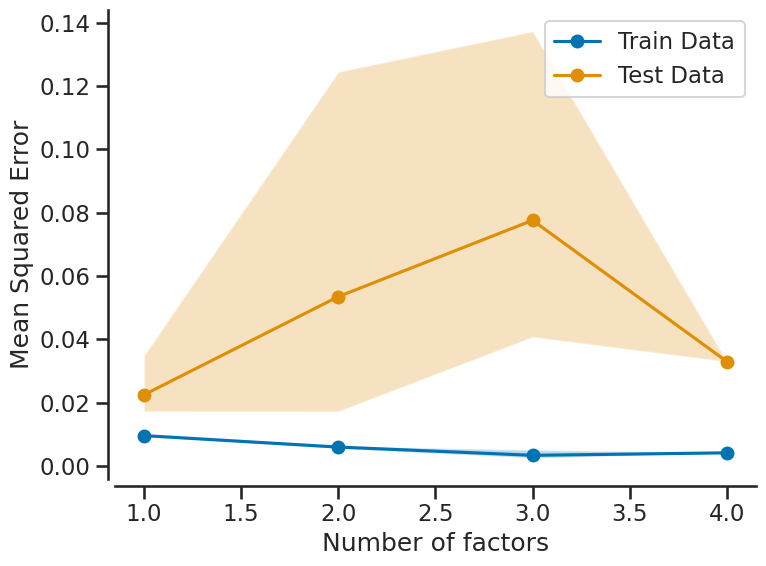

In [33]:
from scipy.signal import argrelextrema

fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

test_mse = groups["MSE"]["mean"]["Test"].values
ranks = groups["MSE"]["mean"]["Test"].index.values

local_min_idx = argrelextrema(test_mse, np.less)[0]

if len(local_min_idx) > 0:
    inflection = ranks[local_min_idx[0]]
    ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

N_FACTORS = 3

#####